In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
employee_test = pd.read_csv("employee_cleaned.csv")
attrition_test = pd.read_csv("attrition_cleaned.csv")
performance_test = pd.read_csv("employee_performance_cleaned.csv")

print("Employee cleaned file:", employee_test.shape)
print("Attrition cleaned file:", attrition_test.shape)
print("Performance cleaned file:", performance_test.shape)

Employee cleaned file: (1000, 12)
Attrition cleaned file: (142, 3)
Performance cleaned file: (1000, 6)


In [4]:
employee_test.describe()

,Employee_ID,Age,Job_Tenure,Distance_From_Home
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.928000,10.303000,24.982000
std,288.819436,11.330984,5.592179,14.565226
min,1.000000,22.000000,1.000000,1.000000
25%,250.750000,31.000000,6.000000,12.000000
50%,500.500000,41.000000,10.000000,24.500000
75%,750.250000,51.000000,15.000000,38.000000
max,1000.000000,60.000000,20.000000,50.000000


In [5]:
performance_test.describe()

,Employee_ID,Performance_Rating,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.918000,2016.941000,105.976000,3.081000,2.992000
std,288.819436,1.407571,4.402602,54.867895,1.363194,1.416313
min,1.000000,1.000000,2010.000000,10.000000,1.000000,1.000000
25%,250.750000,2.000000,2013.000000,59.000000,2.000000,2.000000
50%,500.500000,3.000000,2017.000000,105.000000,3.000000,3.000000
75%,750.250000,4.000000,2021.000000,153.000000,4.000000,4.000000
max,1000.000000,5.000000,2024.000000,200.000000,5.000000,5.000000


In [6]:
attrition_test.describe()

,Employee_ID,Exit_Interview_Score
count,142.000000,142.000000
mean,511.464789,3.112676
std,285.671653,1.379169
min,2.000000,1.000000
25%,272.000000,2.000000
50%,500.000000,3.000000
75%,766.500000,4.000000
max,988.000000,5.000000


In [8]:
print("Attrition Records:", len(attrition_test))
print("Unique Employees:", attrition_test["Employee_ID"].nunique())

print("\nAttrition Status:")
print(attrition_test["Attrition"].value_counts())

print("\nExit Interview Score:")
print(attrition_test["Exit_Interview_Score"].describe())

Attrition Records: 142
Unique Employees: 127

Attrition Status:
Attrition
False    72
True     70
Name: count, dtype: int64

Exit Interview Score:
count    142.000000
mean       3.112676
std        1.379169
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Exit_Interview_Score, dtype: float64


In [10]:
len(attrition_test)

142

In [11]:
attrition_test["Employee_ID"].nunique()

127

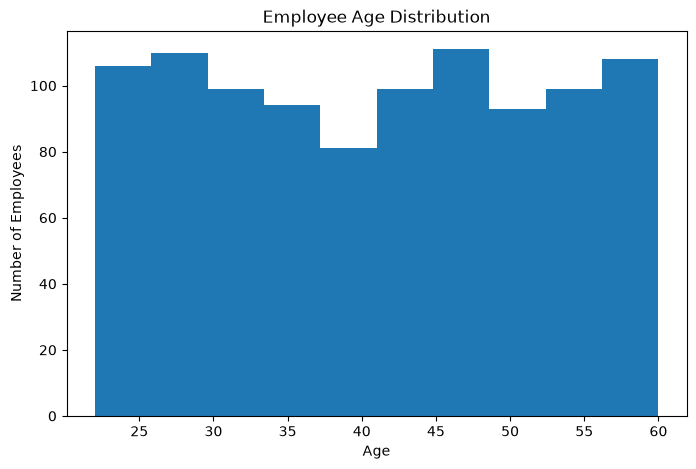

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(employee_test["Age"], bins=10)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

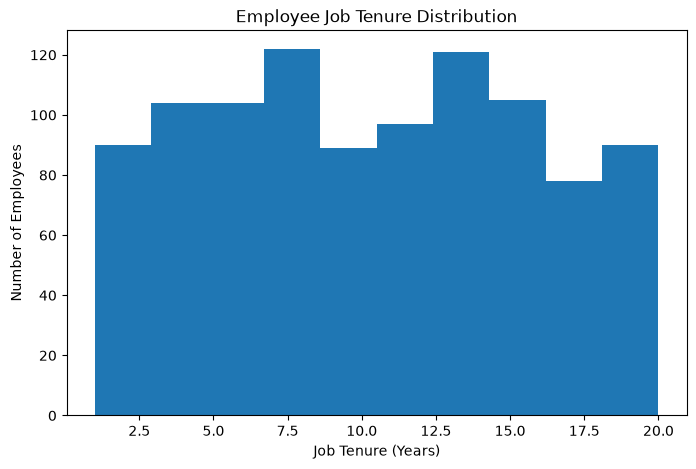

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(employee_test["Job_Tenure"], bins=10)

plt.title("Employee Job Tenure Distribution")
plt.xlabel("Job Tenure (Years)")
plt.ylabel("Number of Employees")

plt.show()

In [16]:
department_counts = employee_test["Department"].value_counts()

display(department_counts)

Department
Finance       194
Operations    169
HR            165
IT            164
Sales         158
Marketing     150
Name: count, dtype: int64

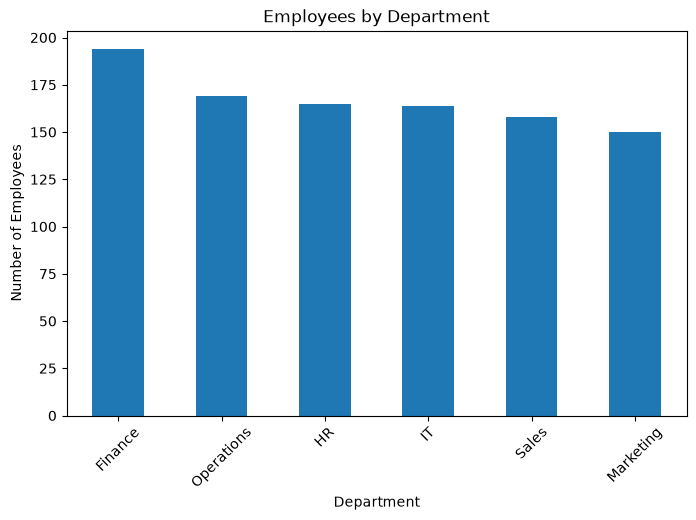

In [17]:
plt.figure(figsize=(8, 5))

department_counts.plot(kind="bar")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45)

plt.show()

In [18]:
performance_counts = performance_test["Performance_Rating"].value_counts().sort_index()

display(performance_counts)

Performance_Rating
1    221
2    197
3    199
4    209
5    174
Name: count, dtype: int64

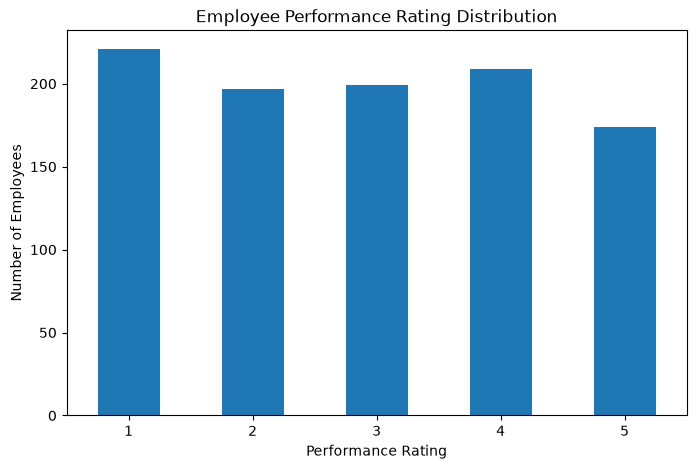

In [19]:
plt.figure(figsize=(8, 5))

performance_counts.plot(kind="bar")

plt.title("Employee Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")

plt.xticks(rotation=0)

plt.show()

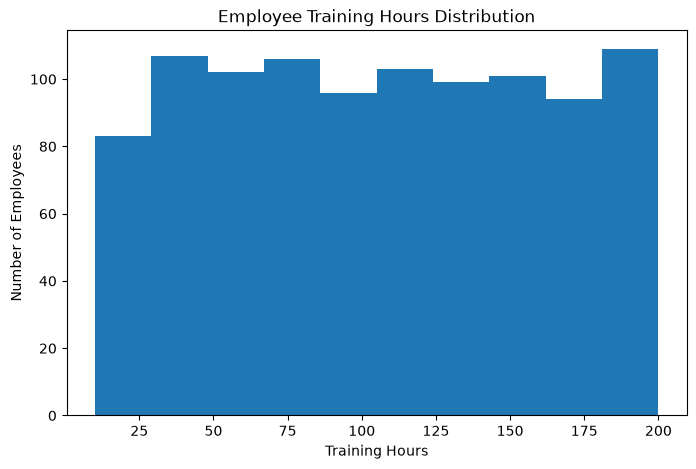

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(performance_test["Training_Hours"], bins=10)

plt.title("Employee Training Hours Distribution")
plt.xlabel("Training Hours")
plt.ylabel("Number of Employees")

plt.show()

In [23]:
worklife_counts = (
    performance_test["Work_Life_Balance"]
    .value_counts()
    .sort_index()
)

display(worklife_counts)


Work_Life_Balance
1    164
2    201
3    223
4    214
5    198
Name: count, dtype: int64

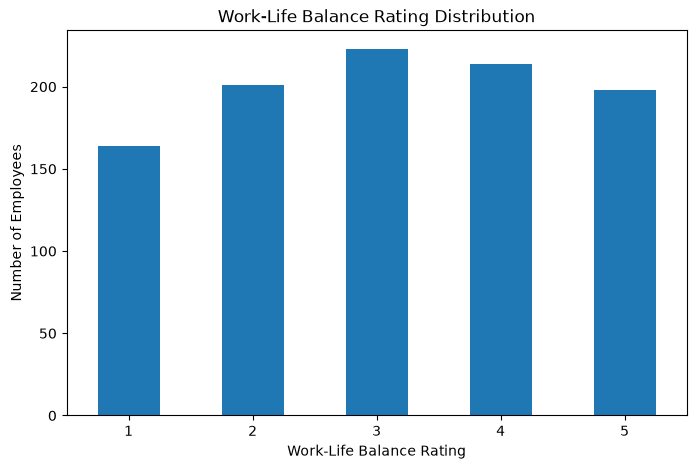

In [25]:
plt.figure(figsize=(8, 5))

worklife_counts.plot(kind="bar")

plt.title("Work-Life Balance Rating Distribution")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")

plt.xticks(rotation=0)

plt.show()

In [27]:
satisfaction_counts = (
    performance_test["Job_Satisfaction"]
    .value_counts()
    .sort_index()
)

display(satisfaction_counts)

Job_Satisfaction
1    199
2    210
3    190
4    202
5    199
Name: count, dtype: int64

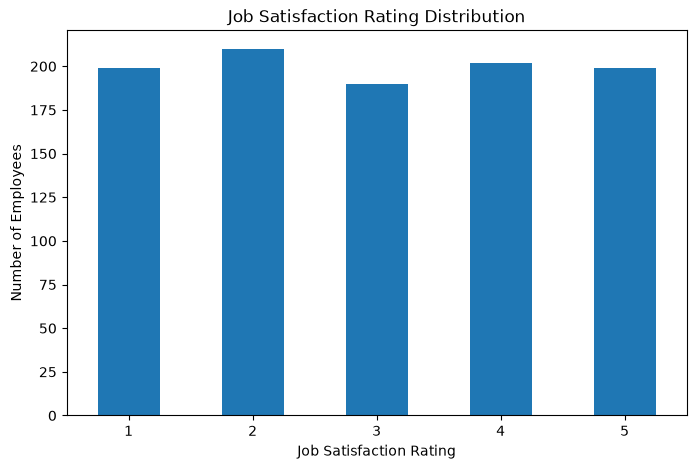

In [28]:
plt.figure(figsize=(8, 5))

satisfaction_counts.plot(kind="bar")

plt.title("Job Satisfaction Rating Distribution")
plt.xlabel("Job Satisfaction Rating")
plt.ylabel("Number of Employees")

plt.xticks(rotation=0)

plt.show()

In [29]:
attrition_employee_summary = (
    attrition_test
    .groupby("Employee_ID")
    .agg(
        Attrition_Records=("Employee_ID", "size"),
        Attrition_Values=("Attrition", lambda x: list(x)),
        Exit_Interview_Scores=(
            "Exit_Interview_Score",
            lambda x: list(x)
        )
    )
    .reset_index()
)

display(attrition_employee_summary.head(20))

,Employee_ID,Attrition_Records,Attrition_Values,Exit_Interview_Scores
0,2,1,[False],[3]
1,11,1,[False],[2]
2,13,1,[False],[3]
3,28,1,[False],[2]
4,42,1,[True],[1]
5,56,1,[False],[5]
6,74,1,[False],[4]
7,79,1,[False],[4]
8,81,1,[True],[3]
9,91,1,[False],[4]


In [31]:
attrition_status_check = (
    attrition_test
    .groupby("Employee_ID")["Attrition"]
    .nunique()
)

print("Employees with consistent attrition status:",
      (attrition_status_check == 1).sum())

print("Employees with conflicting attrition status:",
      (attrition_status_check > 1).sum())

Employees with consistent attrition status: 121
Employees with conflicting attrition status: 6


In [33]:
employee_attrition = (
    attrition_test
    .groupby("Employee_ID")
    .agg(
        Attrition=("Attrition", "max")
    )
    .reset_index()
)

display(employee_attrition.head(20))

,Employee_ID,Attrition
0,2,False
1,11,False
2,13,False
3,28,False
4,42,True
5,56,False
6,74,False
7,79,False
8,81,True
9,91,False


In [34]:
print(employee_attrition["Attrition"].value_counts())

print("\nPercentage:")
print(
    employee_attrition["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
)

Attrition
True     64
False    63
Name: count, dtype: int64

Percentage:
Attrition
True     50.393701
False    49.606299
Name: proportion, dtype: float64


In [36]:
# Combining Dataset
analysis_df = employee_test.merge(
    performance_test,
    on="Employee_ID",
    how="left"
)

print("Analysis dataset shape:", analysis_df.shape)

Analysis dataset shape: (1000, 17)


In [37]:
# Add Employee-Level Attrition
analysis_df = analysis_df.merge(
    employee_attrition,
    on="Employee_ID",
    how="left"
)

print("Final analysis dataset shape:", analysis_df.shape)

Final analysis dataset shape: (1000, 18)


In [39]:
# Handle Employees Without Attrition Records
print("Employees with Attrition information:",
      analysis_df["Attrition"].notna().sum())

print("Employees without Attrition information:",
      analysis_df["Attrition"].isna().sum())

Employees with Attrition information: 127
Employees without Attrition information: 873


In [40]:
# Create a Data Availability Flag
analysis_df["Attrition_Data_Available"] = (
    analysis_df["Attrition"].notna()
)

print(
    analysis_df["Attrition_Data_Available"]
    .value_counts()
)

Attrition_Data_Available
False    873
True     127
Name: count, dtype: int64


In [41]:
# First Attrition Analysis: Department
department_attrition = (
    analysis_df[
        analysis_df["Attrition_Data_Available"]
    ]
    .groupby("Department")
    .agg(
        Employees=("Employee_ID", "nunique"),
        Attrition_Count=("Attrition", "sum")
    )
    .reset_index()
)

department_attrition["Attrition_Rate"] = (
    department_attrition["Attrition_Count"]
    / department_attrition["Employees"]
    * 100
)

display(department_attrition)

,Department,Employees,Attrition_Count,Attrition_Rate
0,Finance,20,8,40.0
1,HR,19,11,57.894737
2,IT,26,10,38.461538
3,Marketing,18,9,50.0
4,Operations,24,13,54.166667
5,Sales,20,13,65.0


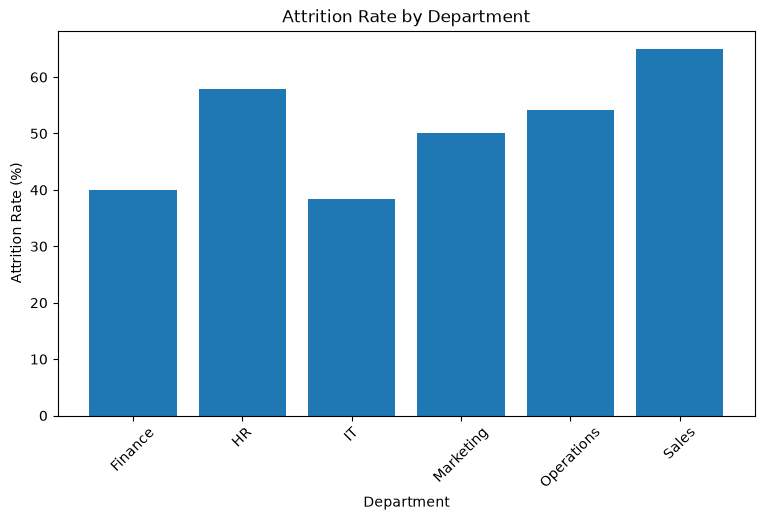

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(
    department_attrition["Department"],
    department_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Create Tenure Bands

In [43]:
analysis_df["Tenure_Group"] = pd.cut(
    analysis_df["Job_Tenure"],
    bins=[0, 5, 10, 15, 20],
    labels=[
        "1-5 Years",
        "6-10 Years",
        "11-15 Years",
        "16-20 Years"
    ]
)

In [44]:
tenure_attrition = (
    analysis_df[
        analysis_df["Attrition_Data_Available"]
    ]
    .groupby("Tenure_Group", observed=True)
    .agg(
        Employees=("Employee_ID", "nunique"),
        Attrition_Count=("Attrition", "sum")
    )
    .reset_index()
)

tenure_attrition["Attrition_Rate"] = (
    tenure_attrition["Attrition_Count"]
    / tenure_attrition["Employees"]
    * 100
)

display(tenure_attrition)

,Tenure_Group,Employees,Attrition_Count,Attrition_Rate
0,1-5 Years,37,18,48.648649
1,6-10 Years,31,15,48.387097
2,11-15 Years,30,16,53.333333
3,16-20 Years,29,15,51.724138


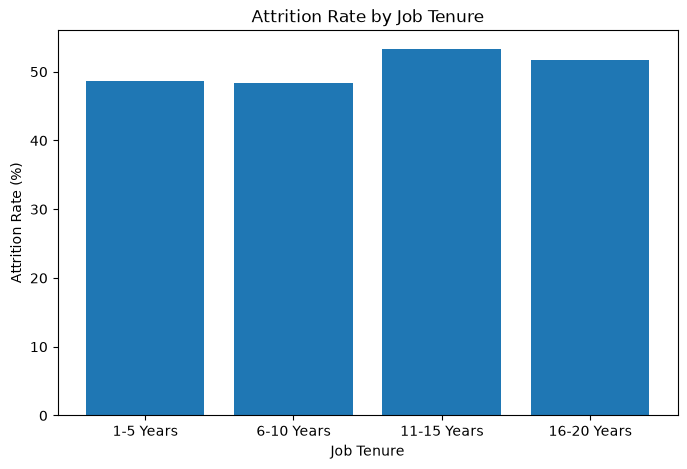

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    tenure_attrition["Tenure_Group"].astype(str),
    tenure_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate by Job Tenure")
plt.xlabel("Job Tenure")
plt.ylabel("Attrition Rate (%)")

plt.show()



In [46]:
# Attrition vs Job Satisfaction
satisfaction_attrition = (
    analysis_df[
        analysis_df["Attrition_Data_Available"]
    ]
    .groupby("Job_Satisfaction")
    .agg(
        Employees=("Employee_ID", "nunique"),
        Attrition_Count=("Attrition", "sum")
    )
    .reset_index()
)

satisfaction_attrition["Attrition_Rate"] = (
    satisfaction_attrition["Attrition_Count"]
    / satisfaction_attrition["Employees"]
    * 100
)

display(satisfaction_attrition)

,Job_Satisfaction,Employees,Attrition_Count,Attrition_Rate
0,1,34,17,50.0
1,2,24,11,45.833333
2,3,22,12,54.545455
3,4,23,11,47.826087
4,5,24,13,54.166667


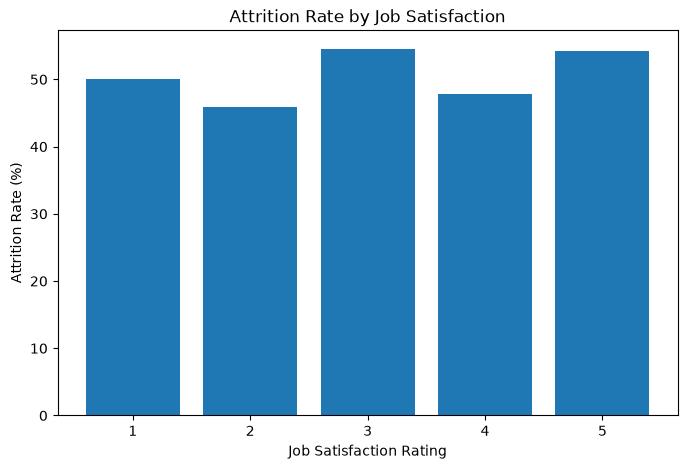

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    satisfaction_attrition["Job_Satisfaction"],
    satisfaction_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Rating")
plt.ylabel("Attrition Rate (%)")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [48]:
performance_attrition = (
    analysis_df[
        analysis_df["Attrition_Data_Available"]
    ]
    .groupby("Performance_Rating")
    .agg(
        Employees=("Employee_ID", "nunique"),
        Attrition_Count=("Attrition", "sum")
    )
    .reset_index()
)

performance_attrition["Attrition_Rate"] = (
    performance_attrition["Attrition_Count"]
    / performance_attrition["Employees"]
    * 100
)

display(performance_attrition)

,Performance_Rating,Employees,Attrition_Count,Attrition_Rate
0,1,28,12,42.857143
1,2,31,18,58.064516
2,3,27,13,48.148148
3,4,24,12,50.0
4,5,17,9,52.941176


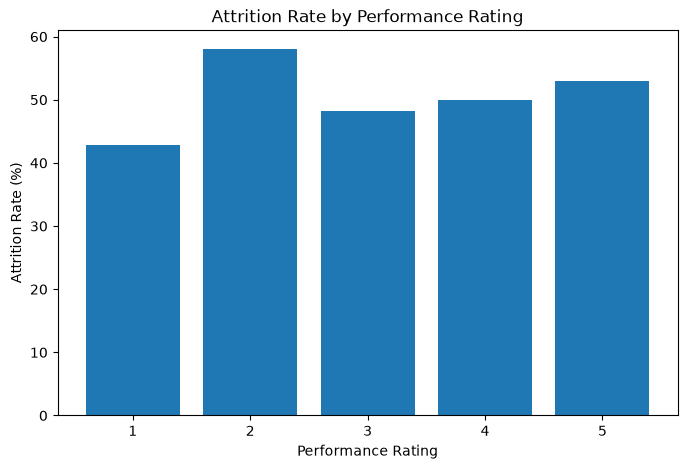

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    performance_attrition["Performance_Rating"],
    performance_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate by Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("Attrition Rate (%)")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [50]:
worklife_attrition = (
    analysis_df[
        analysis_df["Attrition_Data_Available"]
    ]
    .groupby("Work_Life_Balance")
    .agg(
        Employees=("Employee_ID", "nunique"),
        Attrition_Count=("Attrition", "sum")
    )
    .reset_index()
)

worklife_attrition["Attrition_Rate"] = (
    worklife_attrition["Attrition_Count"]
    / worklife_attrition["Employees"]
    * 100
)

display(worklife_attrition)

,Work_Life_Balance,Employees,Attrition_Count,Attrition_Rate
0,1,21,12,57.142857
1,2,28,13,46.428571
2,3,28,16,57.142857
3,4,25,11,44.0
4,5,25,12,48.0


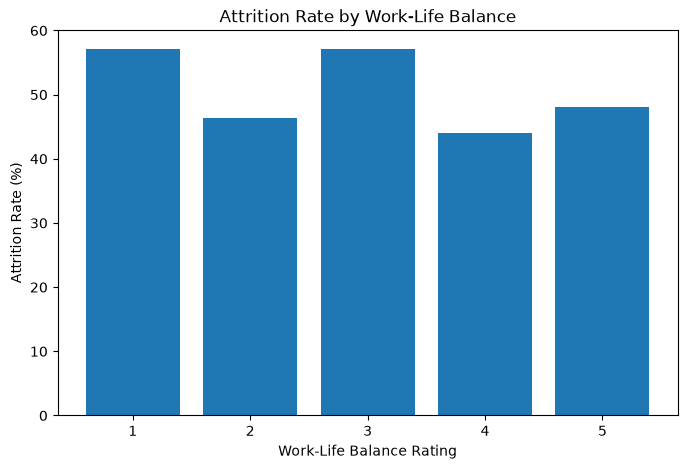

In [51]:
plt.figure(figsize=(8, 5))

plt.bar(
    worklife_attrition["Work_Life_Balance"],
    worklife_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [ ]:
   #                   ATTRITION
   #                       │
   #     ┌─────────────────┼─────────────────┐
   #     ▼                 ▼                 ▼
   # Department          Tenure          Satisfaction
   #     │                 │                 │
   #     └─────────────────┼─────────────────┘
   #                       │
   #             ┌─────────┴─────────┐
   #             ▼                   ▼
   #        Performance         Work-Life Balance